# Imports

In [1]:
from tiled.client import from_uri
import sys
from pathlib import Path
from datetime import datetime
from importlib_metadata import metadata
import signal
import time

# Login to NSLS2 Tiled Server Using BNL Cred

In [ ]:

# connect to the server
TILED_SERVER_URL = "https://tiled.nsls2.bnl.gov"
c = from_uri(TILED_SERVER_URL)


# Access Sandbox

In [2]:
import os

XAS_SANDBOX_URI = 'tst/sandbox/qas/processed/'

# sandbox = c[XAS_SANDBOX_URI]
TILED_API_KEY = os.environ.get('TILED_API_KEY')
client = from_uri('https://tiled.nsls2.bnl.gov', api_key="dc12dba0e4dad618a7e7f752a8791d01960b0105658d36719ffd90aa8f14c48c7c2295d7")


In [5]:
sandbox = client[XAS_SANDBOX_URI]

# Subscribe XAS Sandbox for new entry 

In [24]:
import sys
import time
import threading
from datetime import datetime

# Keep these in globals so other cells can stop/check them
watcher_thread = None
watcher_stop = None
sub = None

def on_new_spectrum(update):
    print("=======", update)
    try:
        entry = update.child()
        now = datetime.now().strftime("%H:%M:%S")

        print(f"\n New spectrum: {update.key}")

        metadata = entry.metadata

        df = entry.read()
        print(f"  {len(df)} data points, columns: {list(df.columns)}")
        print("  Preview:")
        print(df.head(3).to_string(index=False))
    except Exception as e:
        print(f"Error occurred while processing update: {e}")

def start_watching(sandbox):
    global watcher_thread, watcher_stop, sub

    if watcher_thread is not None and watcher_thread.is_alive():
        print("Watcher is already running.")
        return

    existing = list(sandbox)
    print(f"Found {len(existing)} existing entries: {existing}")

    watcher_stop = threading.Event()
    sub = sandbox.subscribe()
    sub.child_created.add_callback(on_new_spectrum)

    def _run():
        print("\nStarting watcher...\n")
        sub.start_in_thread()
        print("Waiting for new spectra...\n")

        try:
            while not watcher_stop.is_set():
                time.sleep(1)
        finally:
            print("Stopping watcher...")
            try:
                sub.disconnect()
            except Exception as e:
                print(f"Error while disconnecting: {e}")

    watcher_thread = threading.Thread(target=_run, daemon=True)
    watcher_thread.start()
    print("Watcher started in background.")

def stop_watching():
    global watcher_thread, watcher_stop, sub

    if watcher_stop is not None:
        watcher_stop.set()

    if watcher_thread is not None:
        watcher_thread.join(timeout=3)

    watcher_thread = None
    watcher_stop = None
    sub = None
    print("Watcher stopped.")

# Starting watcher to subscribe and look for new spectrum entries

In [20]:
start_watching(sandbox)

Found 15 existing entries: ['69cc62d2-cabb-46e9-97eb-c67d88d77092', 'c0cecf82-6ae8-45e5-9661-c816a4dbafc7', 'test_array', '85ba70f8-6d92-40f1-a953-f9400d8826bd', 'fe593bce-b886-46a8-8895-1d1bf2129b04', '403fa23e-7e24-4601-8b25-68979ddb6606', 'bb7b2d6b-3e47-421f-bebb-2124d6855066', '34e97d4f-c5a3-45ba-a371-4667b7f4063b', '0c440c1c-f187-4b69-b440-2563a1ab6f10', 'd3867453-cb9a-43cb-b2a6-afd300cb4898', 'ae563176-c545-4eea-b2d4-0aa5e92a31da', 'd255c76d-2d31-464d-9fdd-39890f2f2245', '533cd08e-b23b-44be-b96d-254d30d9f1ce', 'AnataseNor', 'BaTiO3.nor']

Starting watcher...

Watcher started in background.
Waiting for new spectra...



# XDI Adaptor

In [6]:
# xdi_adapter.py
from io import StringIO
from typing import Any, Dict, Iterator, List, Optional, Tuple, Union

import dask.dataframe
import pandas as pd

from tiled.adapters.array import ArrayAdapter
from tiled.adapters.core import Adapter
from tiled.catalog.orm import Node
from tiled.structures.core import Spec, StructureFamily
from tiled.structures.data_source import DataSource
from tiled.structures.table import TableStructure
from tiled.type_aliases import JSON
from tiled.utils import path_from_uri
from tiled.adapters.utils import init_adapter_from_catalog


class XDIAdapter(Adapter[TableStructure]):
    """Adapter for XDI (.xdi) spectroscopy files."""

    structure_family = StructureFamily.table

    def __init__(
        self,
        data_uri: str,
        structure: Optional[TableStructure] = None,
        *,
        metadata: Optional[JSON] = None,
        specs: Optional[List[Spec]] = None,
    ) -> None:
        filepath = path_from_uri(data_uri)
        df, xdi_metadata = _parse_xdi(str(filepath))

        if metadata is None:
            metadata = xdi_metadata
        else:
            metadata = {**xdi_metadata, **metadata}

        if specs is None:
            specs = [Spec("xdi")]

        self._ddf = dask.dataframe.from_pandas(df, npartitions=1)

        if structure is None:
            structure = TableStructure.from_dask_dataframe(self._ddf)

        super().__init__(structure, metadata=metadata, specs=specs)

    @classmethod
    def from_catalog(
        cls,
        data_source: DataSource[TableStructure],
        node: Node,
        /,
        **kwargs: Optional[Any],
    ) -> "XDIAdapter":
        return init_adapter_from_catalog(cls, data_source, node, **kwargs)

    @classmethod
    def from_uris(
        cls,
        *data_uris: str,
        **kwargs: Optional[Any],
    ) -> "XDIAdapter":
        return cls(data_uris[0], **kwargs)

    def read(self, fields: Optional[List[str]] = None) -> pd.DataFrame:
        df = self._ddf
        if fields is not None:
            df = df[fields]
        return df.compute()

    def read_partition(
        self, indx: int, fields: Optional[List[str]] = None
    ) -> pd.DataFrame:
        df = self._ddf
        if fields is not None:
            df = df[fields]
        return df.compute()

    def get(self, key: str) -> Optional[ArrayAdapter]:
        if key not in self.structure().columns:
            return None
        return ArrayAdapter.from_array(self.read([key])[key].values)

    def __getitem__(self, key: str) -> ArrayAdapter:
        return ArrayAdapter.from_array(self.read([key])[key].values)

    def items(self) -> Iterator[Tuple[str, ArrayAdapter]]:
        yield from (
            (key, ArrayAdapter.from_array(self.read([key])[key].values))
            for key in self._structure.columns
        )


def _parse_xdi(filepath: str) -> Tuple[pd.DataFrame, Dict[str, str]]:
    """Read an XDI file and return (DataFrame, metadata_dict)."""
    metadata: Dict[str, str] = {}
    colspec: Dict[int, str] = {}
    data_lines: List[str] = []

    in_data = False
    saw_triple_slash = False

    def strip_hash(line: str) -> str:
        s = line[1:]
        if s.startswith(" "):
            s = s[1:]
        return s.rstrip("\n")

    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            s = line.strip()

            if s.startswith("#"):
                payload = strip_hash(line).strip()

                if payload == "///":
                    saw_triple_slash = True
                    in_data = True
                    continue

                if payload.startswith("Column."):
                    try:
                        left, right = payload.split(":", 1)
                        _, n_str = left.split(".", 1)
                        colspec[int(n_str.strip())] = " ".join(right.strip().split())
                        continue
                    except Exception:
                        pass

                if ":" in payload:
                    k, v = payload.split(":", 1)
                    k, v = k.strip(), v.strip()
                    if k:
                        metadata[k] = v
                continue

            if not in_data and not saw_triple_slash:
                if s and (s[0].isdigit() or s[0] in "+-."):
                    in_data = True

            if in_data and s:
                if s.startswith("---"):
                    continue
                data_lines.append(line)

    if not data_lines:
        return pd.DataFrame(), metadata

    df = pd.read_csv(
        StringIO("".join(data_lines)),
        sep=r"\s+",
        header=None,
        engine="python",
    )

    if colspec:
        df.columns = [colspec.get(i + 1, f"col{i+1}") for i in range(df.shape[1])]
    else:
        df.columns = [f"col{i+1}" for i in range(df.shape[1])]

    return df, metadata

# Write spectrum to the Sandbox

In [9]:
def send_file(client, xdi_path: Path):
    """Parse one XDI file and write it to Tiled."""
    key = xdi_path.stem
    print(f"\nProcessing {xdi_path.name} with key '{key}'...")
    now = datetime.now().strftime("%H:%M:%S")

    if key in client:
        print(f"  [{now}] {xdi_path.name} — already in Tiled, skipping")
        return

    df, metadata = _parse_xdi(str(xdi_path))

    if df.empty:
        print(f"  [{now}] {xdi_path.name} — no data found, skipping")
        return

    client.write_table(df, key=key, metadata=metadata)
    print(f"  [{now}] {xdi_path.name} — written to Tiled")

spectrum_path = '/home/sairam/LightshowAI/LightshowAI/data_source/raw_data_test.csv'
target = Path(spectrum_path)
if target.is_file() and target.suffix == ".xdi":
        files = [target]
elif target.is_dir():
    files = sorted(target.glob("*.xdi"))
else:
    print(f"Not a valid .xdi file or folder: {target}")
    sys.exit(1)

if not files:
    print(f"No .xdi files found in {target}")
    sys.exit(1)
    
 

print(f"Sending {len(files)} file(s):\n")
for f in files:
    send_file(sandbox, f)

print(f"\nDone. Tiled now has {len(list(sandbox))} entries total.")

Not a valid .xdi file or folder: /home/sairam/LightshowAI/LightshowAI/data_source/raw_data_test.csv


SystemExit: 1

/home/sairam/miniforge3/envs/LightshowAI/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [22]:
stop_watching()

Stopping watcher...
Watcher stopped.


# Create API KEY for the XAS Server

In [16]:
# first create profile 
!tiled profile create --name sairam_dev --set-default "https://tiled.nsls2.bnl.gov"


A profile named 'sairam_dev' already exists. Use --overwrite to overwrite it.
Aborted.


In [ ]:
# create the API key and set it in the environment (do this in your terminal, not here)
# export API_KEY=your_api_key_here
!tiled api_key create

In [8]:
import os

c = from_uri("https://tiled.nsls2.bnl.gov", api_key=os.getenv("API_KEY"))
print(list(c["tst/sandbox/qas/processed/"]))

['69cc62d2-cabb-46e9-97eb-c67d88d77092', 'c0cecf82-6ae8-45e5-9661-c816a4dbafc7', 'test_array', '85ba70f8-6d92-40f1-a953-f9400d8826bd', 'fe593bce-b886-46a8-8895-1d1bf2129b04', '403fa23e-7e24-4601-8b25-68979ddb6606', 'bb7b2d6b-3e47-421f-bebb-2124d6855066', '34e97d4f-c5a3-45ba-a371-4667b7f4063b', '0c440c1c-f187-4b69-b440-2563a1ab6f10', 'd3867453-cb9a-43cb-b2a6-afd300cb4898', 'ae563176-c545-4eea-b2d4-0aa5e92a31da', 'd255c76d-2d31-464d-9fdd-39890f2f2245', '533cd08e-b23b-44be-b96d-254d30d9f1ce', 'AnataseNor', 'BaTiO3.nor', 'NiTiO3.nor', 'Rutile.nor', 'Anatase', 'SrTiO3.nor', 'BaTiO3.nor2', 'BaTiO3.nor3', 'BaTiO3.nor4', 'Anatase2', 'Anatase3', 'BaTiO3.nor5', 'Anatase4', 'Anatase5']


In [8]:
sandbox = client["tst/sandbox/qas/processed/"]
src = sandbox["e4d81869-e6b5-4c7f-8b55-6b940d2b61c1"]
# df = xdi.read()
# print(xdi.read())
# print(xdi.metadata)

# src = sandbox["processed"]["original_name"]
df = src.read()

sandbox.write_table(
    df,
    key="raw_test9",
    metadata=dict(src.metadata),
    specs=src.specs,
)

<DataFrameClient ['timestamp', 'aux3', 'aux4', 'it', 'aux1', 'i0', 'aux2', 'iff', 'ir', 'energy']>

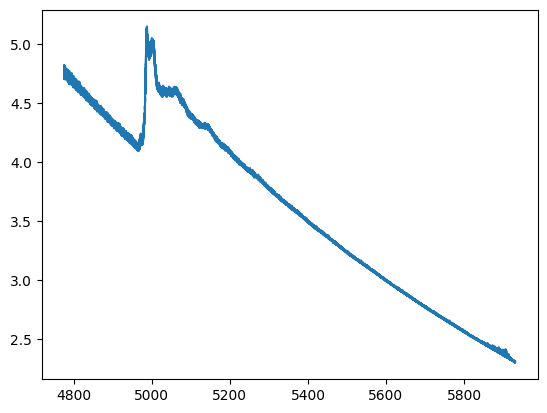

<Figure size 640x480 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
import numpy as np
# plt.plot(df["energy"], df["iff"]/df["i0"])
plt.plot(df["energy"], np.log(df["i0"]/df["it"]))
# plt.plot(df["energy"], df["i0"])
plt.show()
plt.savefig("spectrum.png")

In [12]:
from tiled.client.sync import copy
from tiled.structures.core import StructureFamily


def duplicate(parent, src_key, dest_key, *, on_conflict="error"):
    """
    Duplicate an entry under `parent` from `src_key` to `dest_key`,
    auto-detecting its structure family and writing it back in the
    same format with metadata and specs preserved.

    Parameters
    ----------
    parent : Container
        The Tiled container holding the source entry. The duplicate
        is written into this same container.
    src_key : str
        Existing key to copy from.
    dest_key : str
        New key to write to. Must not already exist unless
        on_conflict='skip' and the family is 'container'.
    on_conflict : {'error', 'skip'}
        If 'skip' and dest_key already exists, return without writing.
    """
    if dest_key in parent:
        if on_conflict == "skip":
            print(f"[duplicate] {dest_key!r} exists; skipping.")
            return parent[dest_key]
        raise KeyError(f"{dest_key!r} already exists in {parent.uri}")

    src = parent[src_key]
    fam = src.structure_family
    metadata = dict(src.metadata)
    specs = list(src.specs) if src.specs else None

    print(f"[duplicate] {src_key!r} -> {dest_key!r}  (family={fam})")

    if fam == StructureFamily.array:
        parent.write_array(
            src.read(),
            key=dest_key,
            metadata=metadata,
            specs=specs,
        )

    elif fam == StructureFamily.table:
        parent.write_table(
            src.read(),
            key=dest_key,
            metadata=metadata,
            specs=specs,
        )

    elif fam == StructureFamily.sparse:
        parent.write_sparse(
            coords=src.read().coords,
            data=src.read().data,
            shape=src.structure().shape,
            key=dest_key,
            metadata=metadata,
            specs=specs,
        )

    elif fam == StructureFamily.awkward:
        parent.write_awkward(
            src.read(),
            key=dest_key,
            metadata=metadata,
            specs=specs,
        )

    elif fam == StructureFamily.container:
        # Create empty container with same metadata/specs, then recursively copy
        parent.create_container(
            key=dest_key,
            metadata=metadata,
            specs=specs,
        )
        copy(src, parent[dest_key])

    else:
        raise NotImplementedError(
            f"Structure family {fam!r} is not handled. "
            f"Supported: array, table, sparse, awkward, container."
        )

    return parent[dest_key]

In [13]:
from tiled.client import from_uri


sandbox = client["tst/sandbox/qas/processed/e4d81869-e6b5-4c7f-8b55-6b940d2b61c1"]

# Duplicate a single entry regardless of whether it's an array, table, or container
duplicate(sandbox, "e4d81869-e6b5-4c7f-8b55-6b940d2b61c1", "raw_copy")

# # Re-runnable without blowing up on existing keys
# duplicate(sandbox, "spectrum_001", "spectrum_001_copy", on_conflict="skip")

KeyError: 'e4d81869-e6b5-4c7f-8b55-6b940d2b61c1'